# **Module 1 Assignment [100 marks]**

Library functions can be used for all operations unless specifically asked not to use library functions.

# Part 1: Linear Regression [10 marks]

In [1]:
# importing important libraries library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression


### Stage 1: Data Preparation for Linear Regression [6 marks]

In [2]:
# loading the data
california_data = fetch_california_housing(as_frame=True)

df = california_data.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Q1: Print the feature names of the dataframe. [2 marks]

In [4]:
### YOUR CODE STARTS HERE ###
# Printing the feature names
print("Feature Names:", california_data.feature_names)
### YOUR CODE ENDS HERE ###

Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Q2: Convert `MedInc` feature to input, and `MedHouseVal` feature to target, and then print the shapes of each (no need to have validation split or test split for this question). [2 marks]

In [7]:
### YOUR CODE STARTS HERE ###
# Find the name of 'MedInc' feature
medinc_feature_name = california_data.feature_names[california_data.feature_names.index('MedInc')]

# Isolate MedInc as the input feature (X)
X = california_data.data[medinc_feature_name].values.reshape(-1, 1)

# Isolate MedHouseVal as the target (y)
y = california_data.target

# Report the shapes of the resulting arrays
print("Shape of X (MedInc):".ljust(25), X.shape)
print("Shape of y (MedHouseVal):".ljust(25), y.shape)
### YOUR CODE ENDS HERE ###

Shape of X (MedInc):      (20640, 1)
Shape of y (MedHouseVal): (20640,)


Q3: Visualize the samples as a 2D scatter plot. [2 marks]

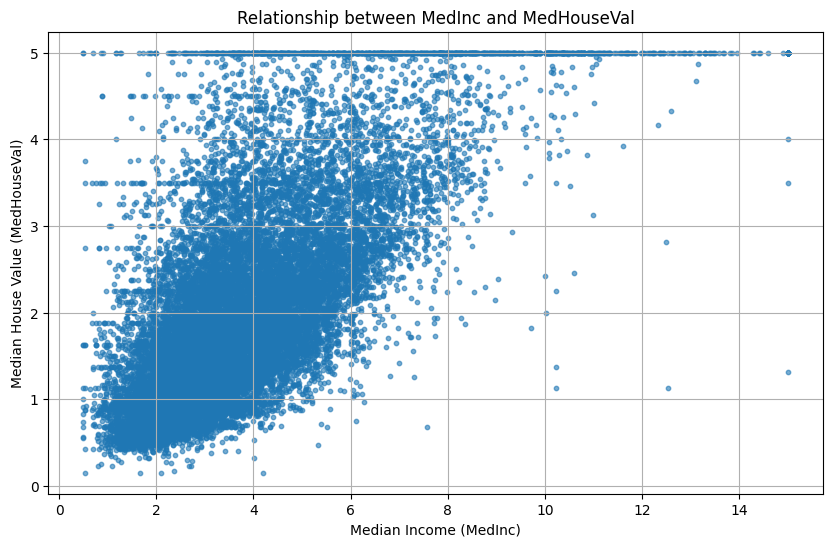

In [8]:
### YOUR CODE STARTS HERE ###
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, s=10)
plt.title('Relationship between MedInc and MedHouseVal')
plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value (MedHouseVal)')
plt.grid(True)
plt.show()
### YOUR CODE ENDS HERE ###

### Stage 2: Model Training and Inference for Linear Regression [4 marks]

Q4: Fit a linear regressor on the data. Print the resultant slope and intercept. [2 marks]

In [9]:
### YOUR CODE STARTS HERE ###
# Initialize and fit the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Report the learned slope (coefficient) and intercept
print(f"Learned Slope (Coefficient): {model.coef_[0]:.4f}")
print(f"Learned Intercept: {model.intercept_:.4f}")
### YOUR CODE ENDS HERE ###

Learned Slope (Coefficient): 0.4179
Learned Intercept: 0.4509


Q5: Visualize the linear regression result by plotting the regression line on top of the 2D scatter plot of `MedInc` and `MedHouseVal`. [2 marks]

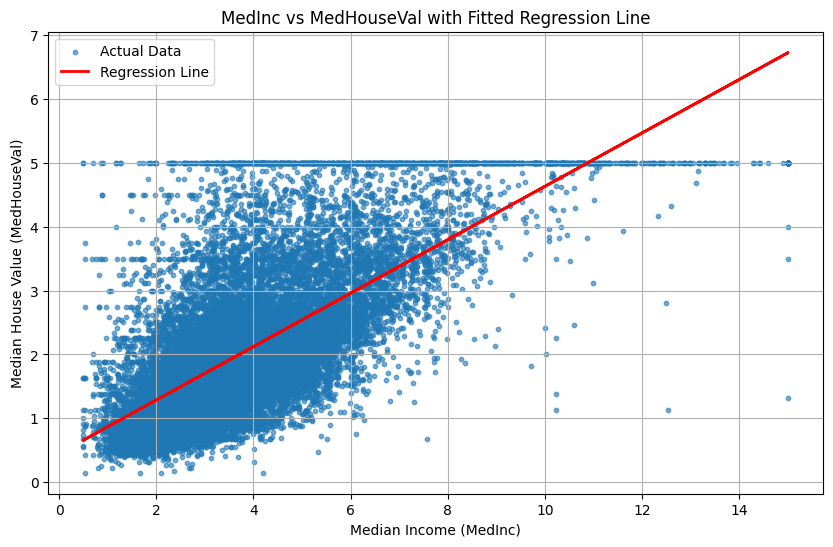

In [10]:
### YOUR CODE STARTS HERE ###
# Predict values using the fitted model
y_predicted = model.predict(X)

# Create the scatter plot again
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, s=10, label='Actual Data')

# Overlay the regression line
plt.plot(X, y_predicted, color='red', linewidth=2, label='Regression Line')

plt.title('MedInc vs MedHouseVal with Fitted Regression Line')
plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value (MedHouseVal)')
plt.grid(True)
plt.legend()
plt.show()
### YOUR CODE ENDS HERE ###

# Part 2: Logistic Regression [10 marks]

In [12]:
# imports
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import model_selection
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
%matplotlib inline

### Stage 1: Data Loading for Logistic Regression [6 marks]

In [13]:
# loading iris dataset
iris = datasets.load_iris()
data=pd.DataFrame(iris['data'],columns=["Petal length","Petal Width","Sepal Length","Sepal Width"])
data['Species']=iris['target']
data['Species']=data['Species'].apply(lambda x: iris['target_names'][x])

Q6: Print the input and output features of 5 different samples from the data. [2 marks]

In [17]:
### YOUR CODE STARTS HERE ###
display(data.sample(5, random_state=22))
### YOUR CODE ENDS HERE ###

,Petal length,Petal Width,Sepal Length,Sepal Width,Species
10,5.4,3.7,1.5,0.2,setosa
115,6.4,3.2,5.3,2.3,virginica
54,6.5,2.8,4.6,1.5,versicolor
146,6.3,2.5,5.0,1.9,virginica
63,6.1,2.9,4.7,1.4,versicolor


Q7: Visualize the features using a pairplot. [2 marks]

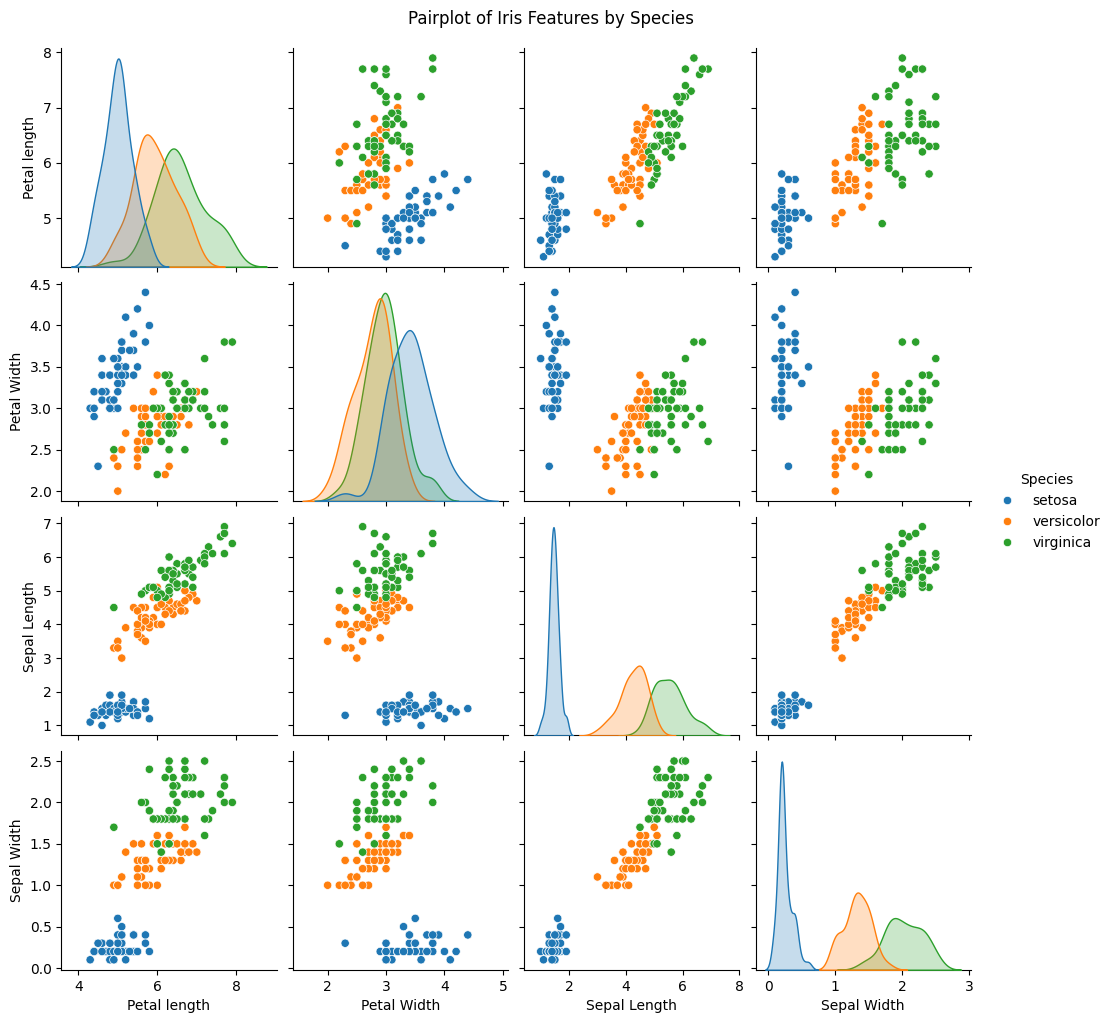

In [19]:
### YOUR CODE STARTS HERE ###
# Create a pairplot to visualize feature relationships and class separability
sns.pairplot(data, hue='Species', diag_kind='kde')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02) # Adjust suptitle position
plt.show()

### YOUR CODE ENDS HERE ###

Q8: Convert the labels into integer class values (0, 1, 2), and then remove the last class (verginica). [2 marks]

In [20]:
### YOUR CODE STARTS HERE ###
# Create a mapping for encoding
species_mapping = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
data['species_encoded'] = data['Species'].map(species_mapping)

# Filter out the 'virginica' class to create a binary classification problem
binary_data_df = data[data['Species'] != 'virginica'].copy()

# Verify the remaining classes and their encoding
print("Classes after filtering:")
print(binary_data_df['Species'].value_counts())
print("Encoded values after filtering:")
print(binary_data_df['species_encoded'].value_counts())

display(binary_data_df.head())
### YOUR CODE ENDS HERE ###

Classes after filtering:
Species
setosa        50
versicolor    50
Name: count, dtype: int64
Encoded values after filtering:
species_encoded
0    50
1    50
Name: count, dtype: int64


,Petal length,Petal Width,Sepal Length,Sepal Width,Species,species_encoded
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


### Stage 2: Data Splitting and Model Training for Logistic Regression [4 marks]

Q9: Split the data into x (input) and y (target). Further split x and y into training and testing subsets, with 80% samples for training and 20% samples for testing. [2 marks]

In [21]:
### YOUR CODE STARTS HERE ###
# Separate features (X) and target (y)
X = binary_data_df.drop(columns=['Species', 'species_encoded'])
y = binary_data_df['species_encoded']

# Create an 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
### YOUR CODE ENDS HERE ###

X_train shape: (80, 4)
X_test shape: (20, 4)
y_train shape: (80,)
y_test shape: (20,)


Q10: Train a logistic regression model on the training subset. Print the weights and the bias. Predict the outputs using testing subset, and print the resultant accuracy. [2 marks]

In [22]:
### YOUR CODE STARTS HERE ###
# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=22, solver='liblinear')

# Train the model on the training set
log_reg_model.fit(X_train, y_train)

# Report learned weights and bias
print("Learned Weights (Coefficients):")
print(log_reg_model.coef_)
print("\nLearned Bias (Intercept):")
print(log_reg_model.intercept_)

# Predict on the test set
y_predicted = log_reg_model.predict(X_test)

# Report the resulting accuracy
accuracy = accuracy_score(y_test, y_predicted)
print(f"\nModel Accuracy on Test Set: {accuracy:.4f}")
### YOUR CODE ENDS HERE ###

Learned Weights (Coefficients):
[[-0.39527454 -1.36797613  2.12109316  0.96203221]]

Learned Bias (Intercept):
[-0.24607687]

Model Accuracy on Test Set: 1.0000


# Part 3: Support Vector Classifier [20 marks]

In [ ]:
# imports
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn import model_selection
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
%matplotlib inline

### Stage 1: Data Preparation for Support Vector Classifier [6 marks]

In [ ]:
# loading the dataset and normalize the features
iris = datasets.load_iris()
X = iris['data'][:,(2,3)]

scaler = StandardScaler()
Xstan = scaler.fit_transform(X)

Q11: Take only two features (petal length and petal width) as input features. Print any 5 samples from the data. [2 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

Q12: Plot the input features as a 2D scatter plot. The two classes should be of shown with different colors. [2 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

Q13: Split the data into x (input) and y (target). Further split x and y into training and testing subsets, with 80% samples for training and 20% samples for testing. [2 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

### Stage 2: Model Training for Support Vector Classifier [14 marks]

Q14: Train a linear support vector classifier (with C=1 and hinge loss) on the training data. Plot the samples from the whole dataset, with decision boundary and margins (the two classes should have different colors). Predict on test set and print the resultant accuracy. [7 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

Q15: Train a linear support vector classifier (with C=1000 and hinge loss) on the training data. Plot the samples from the whole dataset, with decision boundary and margins (the two classes should have different colors). Predict on test set and print the resultant accuracy. [7 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

# Part 4: Bagging [30 marks]

In [ ]:
#imports
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Stage 1: Data Preparation for Bagging Implementation [5 marks]

In [ ]:
# loading the dataset
def load_dataset():
  reg_x, reg_y = fetch_california_housing(return_X_y = True)

  reg_data = np.concatenate((reg_x, np.array(reg_y).reshape(-1, 1)), axis = 1)

  cols = ["feature"+str(i) for i in range(1, 9)]
  cols = cols + ["price(target)"]

  reg_dataset = pd.DataFrame(data = reg_data, columns = cols)

  return reg_dataset

reg_dataset = load_dataset()
print("REGRESSION DATASET : \n", reg_dataset)

Q16: Write a method to get the random indices from train set, and then use the random indices to create a variation of the training set, where some samples are randomly repeated while others are not included. Split the data into x (input) and y (target), each split into training and testing subsets, with 80% samples for training and 20% samples for testing. [5 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

### Stage 2: Training of Linear Regression Models for Bagging Implementation [15 marks]

Q17: Train a linear regression model on the training set with random indices, and print the mean squared error of the predictions on the test set. [3 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

Q18: Fit a second linear regression model on a new variation of the training dataset with a new set of random indices, and print the mean squared error of the average of the predictions of the two linear regression models (this model and the model trianed in the previous question). [4 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

Q19: Fit a third linear regression model on a new variation of the training dataset with a new set of random indices, and print the mean squared error of the average of the predictions of the three linear regression models (this model and the model trianed in the previous two questions). [4 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

Q20: Fit a fourth linear regression model on a new variation of the training dataset with a new set of random indices, and print the mean squared error of the average of the predictions of the four linear regression models (this model and the model trianed in the previous three questions). [4 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

### Stage 3: Interative Variation in Bagging Implementation [10 marks]

Q21: Loop through using 2, 4, 6 ... 24 models and train the models with variations of the training dataset. Print the test mean squared error (take the average mean squared error of the corresponding 2, 4, 6 ... 24 models). Finally, plot the training loss and testing loss for all the cases (2, 4, 6 ... 24 models). [10 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

# Part 5: K-Means Clustering [30 marks]

In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import random
import collections
from sklearn.datasets import load_iris
import pandas as pd

### Stage 1: Data Preparation and Method Definitions for K-Means Clustering Implementation [18 marks]

In [ ]:
# loading the dataset and creating the points
iris = load_iris(as_frame=True)
df = iris.frame

data = df[['petal length (cm)', 'petal width (cm)']]

data.head()

points=data.values.tolist()
points=np.array(points)

Q22: Write a method that takes a data point and a list of centroids, calculates the Euclidean distance between the point and each centroid, and returns the index of the closest centroid. [3 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

Q23: Write a method that takes a dictionary mapping cluster IDs to lists of 2D data points, calculates the new centroid for each cluster by averaging its points, and returns the updated centroids as a NumPy array. [3 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

Q24: Write a method that takes a random seed and an integer "p", sets the seed for reproducibility, and randomly selects "p" initial centroids from a globally defined points dataset, returning them as a NumPy array. [3 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

Q25: Write a method that calculates the Sum of Squared Errors (SSE) for a clustering model. The function should take an array of centroids, a dictionary mapping cluster indices to lists of data points, and the total number of clusters "k", and return the sum of the squared Euclidean distances between every point and its assigned centroid. [3 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

Q26: Write a method that implements the main K-means clustering loop. The function should take the number of clusters "p", a list of data points, and an array of initial centroids seed. It must iteratively assign each point to its nearest centroid, compute the new centroids, and repeat this process until convergence (when the centroids no longer change), ultimately returning the final centroids and a dictionary of the cluster assignments. Whenever kmeans needs to be implemented for any of the following questions, this kmeans implementation from scratch should be used. [6 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

### Stage 2: Finding the Centroids using K-Means Clustering Implementation [12 marks]

Q27: Write a Python script that iterates over cluster counts from 1 to 4, executes the K-means algorithm using a fixed random seed of 42 for initialization, computes the Sum of Squared Errors (SSE) for each configuration, and returns the list of SSE values. Then plot the sum of squared distance in the y-axis and number of clusters in the x-axis. [6 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###

Q28: Use the best number of clusters from elbow method, and visualize the data after applying kmeans on the data using a 2D scatter plot. The two classes should be differently colored, and the centroids should also be shown. [6 marks]

In [ ]:
### YOUR CODE STARTS HERE ###

### YOUR CODE ENDS HERE ###